[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eirasf/GCED-AA2/blob/main/es/lab6/lab6-parte1.ipynb)
# Práctica 6: Redes neuronales convolucionales - Parte 1 - FF vs CNN


### Pre-requisitos. Instalar paquetes

Para la primera parte de este Laboratorio 6 necesitaremos, además de torch, el módulo torchvision para cargar los datos. Además, como habitualmente, fijaremos la semilla aleatoria para asegurar la reproducibilidad de los experimentos.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision
from torchvision import transforms
import os
import numpy as np
import random
from matplotlib import pyplot as plt

# Fijamos la semilla para reproducibilidad
seed = 1234567
os.environ['PYTHONHASHSEED'] = str(seed)
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)


### Carga del conjunto de datos

En esta ocasión trabajaremos con el conjunto de imágenes *mnist*, que representa dígitos escritos a mano. Debemos indicar a nuestro dataloader que haga lotes de 128 elementos.

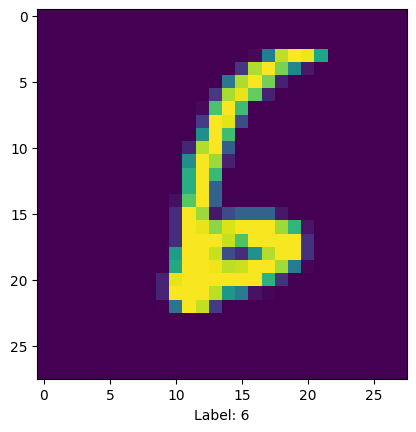

In [5]:
# Cargamos MNIST usando torchvision
transform = transforms.Compose([
    transforms.ToTensor(), # convierte a tensor y escala a [0,1]
])

train_val = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# TODO - Divide train_val en train y val (80/20) (usa la función data.random_split de torch)
train, val = data.random_split(train_val, [48000, 12000], generator=torch.Generator().manual_seed(42))

# TODO - Crea los DataLoaders
batch_size = 128
train_loader = data.DataLoader(train, batch_size=batch_size, shuffle=True)
val_loader = data.DataLoader(val, batch_size=batch_size, shuffle=False)
test_loader = data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

NUM_CLASSES = 10
IMAGE_SHAPE = (1, 28, 28)

# Para comprobar que se ha cargado tomamos un elemento y lo mostramos
im_batch, label_batch = next(iter(train_loader))
ej_imagen = im_batch[0]
plt.imshow(ej_imagen.squeeze())
plt.xlabel(f'Label: {label_batch[0].item()}')
plt.show()


## Ajustando los datos con un red neuronal feed-forward

Vamos a modelar los datos con una red feed-forward que tenga capas de 40, 25 y 16 unidades (todas con activación ReLU). Debemos tener en cuenta que las imágenes son tensores de dimensión 3 (su `shape` es (1,28,28)), mientras que la entrada de nuestras capas Dense debe ser un tensor de dimensión 1. Para adecuar la entrada a lo que necesitamos, vamos a "aplanar" los tensores de las imágenes, que pasarán de `shape` (28,28,1) a `shape` (784). Para ello aplanaremos el lote de (128,1,28,28) a (128, 784) en la función `forward`.

Por último, la salida de nuestro modelo debe tener tantas componentes como clases distintas tiene el conjunto. Como queremos que la salida aproxime la probabilidad de las distintas clases, lo habitual sería poner una función de activación *softmax*, pero en este caso, por razones de eficiencia del entrenamiento, es mejor dejar una salida lineal y posteriormente usar la función de pérdida `nn.CrossEntropyLoss` que espera las salidas vienen en ese formato.

In [6]:
class MLP(nn.Module):
    # TODO - Completa la clase siguiendo las instrucciones dadas en la celda anterior.
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(784, 40), nn.ReLU(),
            nn.Linear(40, 25), nn.ReLU(),
            nn.Linear(25, 16), nn.ReLU(),
            nn.Linear(16, NUM_CLASSES)
        )

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        return self.layers(x)


### Entrenamiento del modelo
Vamos a establecer la función de pérdida, el optimizador (Adam con el LR por defecto) y la métrica que nos servirá para evaluar el rendimiento del modelo entrenado (precisión categórica).

Como intentamos predecir una clase entre varias, nuestra función de pérdida debe ser la [entropía cruzada](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html). Le indicaremos que la salida de nuestra red como *logits* y las etiquetas con el valor numérico de la clase (no en one-hot encoding).

In [7]:
# Evaluación sobre el conjunto de test
def evaluate(model, dataloader, loss_fn):
    # TODO - Completa la función para que devuelva la pérdida y la tasa de acierto
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item() * labels.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

def train_model(model, train_loader, val_loader, loss_fn, optimizer, num_epochs=16):
    # TODO - Completa la función para que haga el entrenamiento devuelva el histórico de pérdidas y tasas de acierto
    train_losses, val_losses = [], []
    model.train_accuracies, model.val_accuracies = [], []
    for epoch in range(num_epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * labels.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
        val_loss, val_accuracy = evaluate(model, val_loader, loss_fn)
        train_losses.append(total_loss / total)
        val_losses.append(val_loss)
        model.train_accuracies.append(correct / total)
        model.val_accuracies.append(val_accuracy)
        print(f'Época {epoch+1}/{num_epochs}: loss={train_losses[-1]:.4f}, val_loss={val_loss:.4f}, acierto={correct/total:.2%}, val_acierto={val_accuracy:.2%}')
    return train_losses, val_losses

# TODO - Define el modelo, función de pérdida y optimizador (Adam con lr=0.001) y haz el entrenamiento durante 16 epochs
ff_model = MLP()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(ff_model.parameters(), lr=0.001)
train_losses, val_losses = train_model(ff_model, train_loader, val_loader, loss_fn, optimizer, num_epochs=16)


Época 1/16: loss=0.8674, val_loss=0.4040, acierto=74.57%, val_acierto=88.65%
Época 2/16: loss=0.3204, val_loss=0.2962, acierto=90.71%, val_acierto=91.40%
Época 3/16: loss=0.2518, val_loss=0.2557, acierto=92.69%, val_acierto=92.65%
Época 4/16: loss=0.2131, val_loss=0.2359, acierto=93.75%, val_acierto=93.08%
Época 5/16: loss=0.1876, val_loss=0.2137, acierto=94.42%, val_acierto=93.83%
Época 6/16: loss=0.1673, val_loss=0.1940, acierto=95.01%, val_acierto=94.28%
Época 7/16: loss=0.1515, val_loss=0.1861, acierto=95.45%, val_acierto=94.33%
Época 8/16: loss=0.1379, val_loss=0.1811, acierto=95.89%, val_acierto=94.67%
Época 9/16: loss=0.1259, val_loss=0.1665, acierto=96.24%, val_acierto=95.01%
Época 10/16: loss=0.1152, val_loss=0.1564, acierto=96.56%, val_acierto=95.37%
Época 11/16: loss=0.1069, val_loss=0.1569, acierto=96.79%, val_acierto=95.38%
Época 12/16: loss=0.0996, val_loss=0.1516, acierto=97.04%, val_acierto=95.51%
Época 13/16: loss=0.0938, val_loss=0.1541, acierto=97.20%, val_acierto=95

### Verificación del rendimiento
Aprovecharemos el conjunto de test para comprobar la capacidad de generalización de nuestro modelo. Puedes también visualizar la curva de entrenamiento para identificar potenciales problemas con el entrenamiento.

In [8]:
# TODO - Evalúa sobre el conjunto de test
ff_test_loss, ff_test_accuracy = evaluate(ff_model, test_loader, loss_fn)
print(f'Pérdida test: {ff_test_loss:.4f}; tasa de acierto: {ff_test_accuracy:.2%}')

Pérdida test: 0.1309; tasa de acierto: 96.33%


Si todo ha ido correctamente deberías haber obtenido un valor de precisión sobre el conjunto de test comparable a los obtenidos con los conjuntos de entrenamiento y validación, lo que indica que el modelo generaliza bien a otros datos del conjunto original pero... ¿tenemos un buen modelo?

Vamos a comprobar la robustez del modelo haciendo pequeños desplazamientos de las imágenes originales. Utilizaremos un pequeño modelo que aplique una traslación aleatoria de hasta un 10% del tamaño de la imagen a cada una de las imágenes de test. Nos ayudaremos del módulo `transforms` incluido en `torchvision` y en particular de [`transforms.RandomAffine`](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.RandomAffine.html) para hacer traslacciones de hasta un 10% del tamaño de imagen en cualquier dirección.

In [9]:
# Data augmentation: aplicamos una pequeña traslación usando torchvision.transforms
transform_translated = transforms.Compose([
    # TODO - Utiliza RandomAffine para hacer traslacciones de hasta un 10% en cualquier dirección
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
])

# Creamos un dataset de test transformado
test_translated = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_translated)
test_translated_loader = data.DataLoader(test_translated, batch_size=batch_size, shuffle=False)


Comprobemos ahora la precisión sobre este nuevo conjunto de imágenes que han sido ligeramente desplazadas.

In [10]:
# TODO - Evalúa sobre el conjunto de test desplazado
ff_translated_loss, ff_translated_accuracy = evaluate(ff_model, test_translated_loader, loss_fn)
print(f'Pérdida test desplazado: {ff_translated_loss:.4f}; tasa de acierto: {ff_translated_accuracy:.2%}')


Pérdida test desplazado: 1.7080; tasa de acierto: 67.92%


Si todo ha ido bien, deberías haber comprobado que estas pequeñas traslaciones son suficientes para que la precisión del modelo baje sustancialmente. Las redes feed-forward no son robustas ante este tipo de perturbaciones.

## Comparativa con una red convolucional

Declara ahora un modelo convolucional con la siguiente arquitectura:
 1. [Convolución 2D](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) de 8 filtros y tamaño de kernel 3, con activación ReLU
 1. [Pooling 2D](https://docs.pytorch.org/docs/2.8/generated/torch.nn.MaxPool2d.html) tomando el máximo de cada grupo de 2x2
  1. [Convolución 2D](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) de 8 filtros y tamaño de kernel 3, con activación ReLU
 1. [Pooling 2D](https://docs.pytorch.org/docs/2.8/generated/torch.nn.MaxPool2d.html) tomando el máximo de cada grupo de 2x2
 1. Capa Densa (requiere aplanado previo) de 32 unidades y activación ReLU
 1. Capa de salida

Define el nuevo modelo, entrénalo y haz las verificaciones posteriores para observar la diferencia.

In [11]:
class ConvModel(nn.Module):
    # TODO - Completa la clase según las instrucciones
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 8, kernel_size=3), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(8 * 5 * 5, 32), nn.ReLU(),
            nn.Linear(32, NUM_CLASSES)
        )

    def forward(self, x):
        return self.layers(x)

# TODO - Define el modelo, función de pérdida y optimizador (Adam con lr=0.001) y haz el entrenamiento durante 16 epochs
conv_model = ConvModel()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(conv_model.parameters(), lr=0.001)
train_losses, val_losses = train_model(conv_model, train_loader, val_loader, loss_fn, optimizer, num_epochs=16)

# TODO - Haz las evaluaciones como en hiciste con ff_model
conv_test_loss, conv_test_accuracy = evaluate(conv_model, test_loader, loss_fn)
conv_translated_loss, conv_translated_accuracy = evaluate(conv_model, test_translated_loader, loss_fn)
print(f'CNN test: pérdida={conv_test_loss:.4f}, acierto={conv_test_accuracy:.2%}')
print(f'CNN test desplazado: pérdida={conv_translated_loss:.4f}, acierto={conv_translated_accuracy:.2%}')


Época 1/16: loss=0.7288, val_loss=0.3260, acierto=77.34%, val_acierto=90.48%
Época 2/16: loss=0.2572, val_loss=0.2209, acierto=92.26%, val_acierto=93.40%
Época 3/16: loss=0.1853, val_loss=0.1623, acierto=94.40%, val_acierto=95.09%
Época 4/16: loss=0.1479, val_loss=0.1400, acierto=95.59%, val_acierto=95.62%
Época 5/16: loss=0.1239, val_loss=0.1238, acierto=96.20%, val_acierto=96.22%
Época 6/16: loss=0.1088, val_loss=0.1086, acierto=96.73%, val_acierto=96.79%
Época 7/16: loss=0.0978, val_loss=0.0996, acierto=97.02%, val_acierto=97.23%
Época 8/16: loss=0.0876, val_loss=0.1115, acierto=97.38%, val_acierto=96.83%
Época 9/16: loss=0.0830, val_loss=0.0979, acierto=97.50%, val_acierto=97.14%
Época 10/16: loss=0.0744, val_loss=0.0874, acierto=97.72%, val_acierto=97.42%
Época 11/16: loss=0.0719, val_loss=0.0833, acierto=97.74%, val_acierto=97.52%
Época 12/16: loss=0.0670, val_loss=0.0835, acierto=97.93%, val_acierto=97.63%
Época 13/16: loss=0.0643, val_loss=0.0779, acierto=97.99%, val_acierto=97

### Reflexiones sobre la comparativa
 - ¿Qué has observado en el rendimiento?
 - ¿Cuántos parámetros tiene la red convolucional respecto a la *feed-forward*
 - ¿Cómo ha cambiado el tiempo de ejecución?
 - ¿Es más robusta frente a los desplazamientos esta red?